# MIT91207 Machine Learning: Assignment 2

Name: Mugisha Jean Claude
Registration number: 26016815
Programme: MSc Information Technology, Level 9
Module: MIT91207 Machine Learning
Lecturer: Dr Gustave Udahemuka

In [1]:
%matplotlib inline
import sys, os, pandas, numpy, sklearn, scipy, matplotlib
print('python      ', sys.version.split()[0])
for m in (pandas, numpy, sklearn, scipy, matplotlib):
    print(f'{m.__name__:12s}', m.__version__)
print('\ndatasets:', sorted(f for f in os.listdir('data') if f.endswith('.csv')))

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

python       3.9.6
pandas       2.3.3
numpy        2.0.2
sklearn      1.6.1
scipy        1.13.1
matplotlib   3.9.4

datasets: ['credit.csv', 'crimes.csv', 'home.csv', 'loan.csv', 'prices.csv']


# Question One: a decision tree that memorises

## 1(a) The gap between 99.6% and 59.4%

The model has overfitted, and the configuration makes it close to inevitable.

The evidence is the size and direction of the gap. A 40.2 percentage point fall from
training to validation is not sampling noise; with a validation set of any reasonable
size the standard error on an accuracy estimate is a couple of points at most, so a gap
of this magnitude is structural. The direction rules out the alternatives: a model that
is too simple fails on both sets together, and a model with a data problem such as
label noise usually underperforms on both. Only a model that has fitted the training
sample specifically can do nearly perfectly on it and barely better than guessing
elsewhere.

The configuration supplies the mechanism. With `max_depth = None` the tree grows until
every leaf is pure or cannot be split further, and with `min_samples_leaf = 1` a leaf
containing a single customer is permitted. Together these place no limit on complexity
at all, so the tree keeps partitioning until it has isolated individual training
records. Training accuracy of 99.6% is therefore not a sign that the model learned
something; it is close to what this configuration produces by construction on almost
any dataset.

The validation figure of 59.4% is the honest estimate of what the model knows. For a
churn problem, where the majority class typically sits around 70% to 75%, that number
is worth comparing against a classifier that always predicts "stays". If the majority
class exceeds 59.4%, the tree is performing worse than a model with no inputs, which
would be the strongest possible evidence that the depth has bought nothing.

## 1(b) Bias and variance here

Bias is the error from a model that cannot represent the underlying relationship, the
part that persists no matter how much data is supplied. Variance is the error from
sensitivity to the particular training sample, the part that changes when the sample
changes. Total expected error decomposes into these two plus irreducible noise, and the
two trade against each other as complexity moves.

This model has high variance and low bias.

Low bias follows from the training accuracy. A hypothesis class that reaches 99.6% on
the training data plainly has the capacity to represent the relationship; nothing is
being systematically missed. High variance follows from the gap. The decision boundary
has been fitted to the noise in this particular sample, so a different draw from the
same population would produce a substantially different tree and substantially
different predictions.

A useful way to see it: fit the same configuration on two disjoint halves of the
training data and compare the resulting trees. Under high variance they will differ in
their root split, not merely in their leaves. Under high bias they would agree with each
other and both be wrong.

## 1(c) What the two settings do to complexity

`max_depth` caps the number of successive splits on any path from root to leaf. Setting
it to `None` removes the cap entirely, so the depth is limited only by the data. Since
each additional level can double the number of leaves, the number of regions the tree
carves out can grow exponentially with depth, and each region is fitted from fewer and
fewer observations.

`min_samples_leaf` sets the smallest number of training observations a leaf may contain.
At 1, a split is allowed even when it isolates a single customer, so the tree can
manufacture a rule that describes exactly one person. Any prediction resting on one
observation carries the full variance of that observation.

The two interact rather than acting separately. A depth cap alone still permits tiny
leaves within the permitted depth, and a leaf-size floor alone still permits a very deep
tree of narrow splits. Left at `None` and `1` they remove both constraints at once,
which is why the model can drive training error almost to zero.

## 1(d) Overfitting, underfitting, and what to change

Overfitting is learning the training sample rather than the population: low training
error, high error on unseen data, the two separated by a large gap. Underfitting is
failing to learn either: high training error and high validation error, with the two
close together. The diagnostic is not the level of either number alone but the size of
the gap alongside them.

This model is overfitting, on the evidence in 1(a).

Two configuration changes would help, and they attack complexity from different
directions.

Limit the depth. Setting `max_depth` to a small value, searched over a grid instead of guessed, forces the tree to spend its splits on the partitions that separate the classes
best, and prevents the long chains of narrow splits that fit noise. This is the blunter
instrument and usually the more effective one.

Raise the leaf floor. Setting `min_samples_leaf` to something like 20 or 50 requires
every prediction to rest on a group rather than an individual, which is what makes leaf
estimates stable. `min_samples_split` acts similarly one level up, and
`ccp_alpha` offers a more principled alternative: cost-complexity pruning grows the
tree fully and then removes the branches whose contribution does not justify their
complexity, with the trade governed by a single parameter that cross-validation can
select.

Both values should be chosen by cross-validated search on the training data, for the
reason set out in Question Three: tuning against a single fixed validation set and then
reporting that set's score overstates what the model will do on new customers.

# Question Two: parametric against non-parametric

## 2(a) Reading the two sets of scores

| Model | Training F1 | Validation F1 | Gap |
|---|---|---|---|
| Linear SVM | 0.79 | 0.76 | 0.03 |
| Decision Tree | 0.99 | 0.63 | 0.36 |

A parametric model commits in advance to a fixed functional form with a fixed number of
parameters, and learning consists of estimating those parameters. A linear SVM assumes
the classes can be separated by a hyperplane, so whatever the sample size, it estimates
one weight per feature plus an intercept. The size of the model does not grow with the
data.

A non-parametric model does not fix the form in advance, and its effective number of
parameters grows with the sample. A decision tree decides how many splits to make and
where, so the structure is read off the data rather than imposed on it. On a large
sample the tree can become very large indeed.

That structural difference is what produces their inductive biases, meaning the
assumptions each makes when generalising beyond what it has seen. The SVM's bias is
strong and explicit: it believes the boundary is linear, and it will impose that belief
even where it is wrong, which is why it cannot chase noise but also cannot capture a
genuinely curved boundary. The tree's bias is weak and different in kind: it assumes the
boundary is made of axis-parallel rectangles, and because it can use arbitrarily many of
them, it can approximate almost any shape, including the shape of the noise. Weak bias
buys flexibility and pays for it in variance.

The decision tree shows the stronger evidence of overfitting, by a wide margin. Its gap
of 0.36 is twelve times the SVM's 0.03, and the pattern is the signature: near-perfect
training performance with validation performance far below it. The SVM's small gap says
its capacity is well matched to the problem; it is not memorising, because its form does
not permit memorising.

The practical conclusion is the one that the table makes uncomfortable for the tree. The
SVM is the better model on this evidence, with a validation F1 of 0.76 against 0.63, and
the tree's superior training score is not an argument in its favour but the reason for
its worse validation score. Two qualifications are worth stating. Single-split estimates
carry uncertainty, so the comparison should be repeated under cross-validation before
the SVM is declared the winner. And the tree has not been tuned: the comparison is
between a well-matched linear model and an unconstrained tree, so the fair contest is
against a tree whose complexity has been controlled by the parameters in 2(b).

## 2(b) Three hyperparameters for the grid

max_depth. Controls the maximum number of splits along any root-to-leaf path.
Lowering it stops the tree early, so the leaves cover broader regions and each is
estimated from more observations; raising it lets the tree keep subdividing. Because the
number of leaves can double with each level, this parameter governs complexity more
directly than any other, and constraining it is usually the single most effective
intervention against a 0.36 gap. Sensible grid: 3, 5, 7, 10, 15, None.

min_samples_leaf. Controls the minimum observations permitted in a terminal node. A
split that would leave fewer than this on either side is rejected, so raising it prunes the tree upward from the leaves and prevents leaves built on one or two transactions. The
effect on generalisation is direct: a leaf's predicted probability is estimated from the
observations it contains, so a floor of 50 gives an estimate with roughly a seventh of
the standard error of one based on a single observation. For fraud detection specifically
the floor must be set with the class imbalance in mind, since too high a value can
eliminate the small pure-fraud leaves that carry the signal. Sensible grid: 1, 5, 20, 50, 100.

min_samples_split. Controls the minimum observations a node must hold before it is
eligible to be split at all. It acts one level above `min_samples_leaf`, halting growth
before a split is attempted rather than rejecting the result afterwards, which prunes
whole branches instead of trimming their ends. Raising it produces a shallower tree with
fewer, better-populated decision regions and reduces variance for the same reason.
Sensible grid: 2, 10, 50, 100.

A fourth worth including is `ccp_alpha`, the cost-complexity pruning parameter, which
differs from the three above in that it prunes after growth instead of constraining it during growth. That lets the tree discover useful deep structure first and remove only
the branches whose accuracy gain does not justify their complexity, which often
outperforms pre-pruning at the same effective size.

These parameters interact, so they should be searched jointly over a grid rather than
tuned one at a time, and scored on F1 or average precision rather than accuracy, for the
reason set out in Question Four.

# Question Three: validation done properly

## 3(a) Fifty configurations against one fixed validation set

The practitioner has produced a number that cannot be trusted, and the reason is
selection, not modelling.

Each of the 50 validation scores is an estimate of true performance carrying random
error from the particular composition of that validation set. Taking the maximum of 50
such estimates does not return the best model's true performance; it returns that model's true performance plus the largest favourable error among the 50 draws. The
maximum of a set of noisy estimates is biased upward, and the bias grows with the number
of candidates. With 50 configurations, the winner is partly whichever one happened to
suit the idiosyncrasies of that specific validation split.

The mechanism is that the validation set has been used 50 times to make a choice, so
information about it has flowed into the selected model. It is no longer held out in any
meaningful sense. It has become part of the training procedure, and reporting its score
as an estimate of performance on new data is reporting training performance under a
different name.

Cross-validation should be incorporated by replacing the single fixed split with k folds
inside the training data. Each configuration is scored as the mean across folds, which
reduces the variance of each estimate and therefore reduces how much the maximum is
inflated. It does not eliminate the problem, because the folds are still being reused
across 50 candidates, but averaging over k estimates instead of relying on one makes
each comparison far more stable.

The procedure that separates selection from evaluation is a three-way split, or
equivalently nested cross-validation.

The three-way split holds out a test set at the outset and does not touch it again.
Within the remainder, cross-validation selects the configuration. The chosen
configuration is refitted on the full remainder, and scored once on the test set. That
single score is unbiased because the test set played no part in the selection.

Nested cross-validation generalises this and is preferable when data is limited. An
inner loop selects the hyperparameters; an outer loop estimates the error of the entire
procedure including the selection. What it estimates is subtly different and more
useful: not the performance of one chosen model, but the performance of the method that
chooses models, which is what will be run again on new data.

The discipline underneath both is that any dataset used to make a decision cannot also
be used to evaluate that decision.

## 3(b) K-Fold and Stratified K-Fold with an 11% minority

K-Fold cross-validation partitions the data into k roughly equal folds. The model is
trained k times, each time on k−1 folds and scored on the fold held back, so every
observation is used for validation exactly once and for training k−1 times. The k scores
are averaged for a performance estimate and their spread indicates its stability. The
advantage over a single split is that the estimate does not depend on one arbitrary
partition, and every observation contributes to the evaluation.

Stratified K-Fold adds one constraint: each fold preserves the class proportions of the
full dataset. With an 11% minority, every fold contains approximately 11% minority cases
rather than whatever the random partition delivers.

Two distinct problems arise without stratification at this imbalance.

The first is variance in the estimate. With 11% minority and, say, 1,000 observations
in 5 folds, each fold of 200 holds about 22 minority cases in expectation, but the
random count follows a binomial distribution with a standard deviation of roughly 4.4.
A fold might hold 15 or 30. Metrics that depend on the minority class, which for an
imbalanced problem are the only metrics that matter, are computed on that small and
varying denominator, so recall estimated on 15 cases moves in steps of 6.7 percentage
points per case. The fold-to-fold scores scatter for reasons that have nothing to do
with the model, and the average inherits that noise.

The second is bias in the fits. Each training set has a different class balance, so each
of the k models is fitted on a slightly different problem. The k scores are therefore
not repeated measurements of one quantity, which is what averaging assumes.

At more extreme imbalance a third failure appears: a fold can contain no minority cases
at all, leaving recall undefined and F1 either undefined or silently zero. At 11% with
reasonable fold sizes that is unlikely, but it is the limiting case of the same problem,
and it is why stratification is the default for classification and not an optimisation.

Stratification costs nothing. There is no accuracy trade and no computational penalty,
which is why `StratifiedKFold` should be the default for any classification problem and
`KFold` reserved for regression.

# Question Four: imbalance and an automated workflow

## 4(a) Why 98% accuracy can mean nothing

Let the dataset contain N transactions, of which 2% are fraudulent and 98% legitimate.
A classifier that predicts "Legitimate" for every transaction produces:

```
TP = 0            FP = 0
FN = 0.02N        TN = 0.98N

accuracy    = (TP + TN) / N = (0 + 0.98N) / N = 0.98      = 98%
recall      = TP / (TP + FN) = 0 / (0 + 0.02N) = 0        = 0%
precision   = TP / (TP + FP) = 0 / 0, undefined, reported as 0
F1          = 2PR / (P + R) = 0
```

On 100,000 transactions that is 98,000 correct classifications and 2,000 frauds, every
single one of them missed.

Accuracy misleads here because it is a weighted average in which the weights are the
class frequencies, so at 98% prevalence the majority class contributes 98% of the score.
A model can therefore be right about the easy 98% and wrong about the entire 2% that the
system exists to find. The arithmetic gets worse as imbalance deepens: at 0.2% fraud the
same do-nothing classifier scores 99.8%.

For an early-warning system the asymmetry compounds it. Accuracy counts a missed fraud
and a false alarm as one error each, but a missed fraud is a completed theft while a
false alarm is a few minutes of analyst review. Treating them as equal encodes a
preference no fraud team holds. The metrics that survive are the ones computed on the positive class alone: recall, precision, F1, and average precision, which summarises the
precision-recall curve across thresholds instead of committing to one.

## 4(b) The workflow

The script is in this notebook, run on the supplied `credit.csv`: 1,000,000 card
transactions, seven predictors and a binary fraud flag at 8.740% positive.

```
rows 1,000,000   predictors 7, all numeric   fraud 87,403 = 8.740%   ratio 1 : 10
train 750,000 (8.740% positive)   test 250,000 (8.740% positive)

baseline unconstrained tree   depth 7   leaves 35
                              train F1 1.0000   test F1 0.9999

grid search                   40 configurations x 5 stratified folds
                              scored on average precision
best                          max_depth 8, min_samples_leaf 1, class_weight balanced
                              cross-validated average precision 0.9995

held-out test set
  F1-score          0.9999
  average precision 0.9999
  (accuracy 1.0000, against 0.9126 for always predicting the majority class)

confusion matrix        predicted legitimate   predicted fraud
  actual legitimate               228,148                   1
  actual fraud                          2              21,849
```

Three design points carry the workflow. The search is scored on average precision, for
the reason in 4(a). The folds are stratified, so each holds the same 8.740% and the fold
scores are comparable. And the grid is fitted on the training partition alone, so the
test score remains an honest estimate. One practical addition: at 750,000 training rows a
40-point grid over five folds is 200 tree fits, so the search runs on a stratified
subsample of 150,000 and the winning configuration is then refitted on all 750,000.

Two results need comment, because both cut against what the question's framing suggests.

The unconstrained tree did not overfit. With `max_depth=None` and `min_samples_leaf=1`,
the settings that produced Question One's 40-point collapse, this tree stopped at depth 7
with 35 leaves and scored 1.0000 on training against 0.9999 on test. It stopped because
the nodes became pure, not because a limit stopped it. Unlimited capacity produces
overfitting only when the data contains noise for the model to fit, and this data barely
does.

A score of 0.9999 demands scrutiny before it is reported, so I checked whether it came
from leakage. It does not. No single predictor carries the signal: the strongest,
`ratio_to_median_purchase_price`, reaches an average precision of 0.4949 on its own, and
the weakest reach 0.09. The separation is genuinely multivariate, and every one of the
seven is a property of the transaction observable as it happens, so none is derived from
the label. The dataset is synthetic and its generating rule is close to deterministic,
which is a property of this file rather than a finding about fraud detection. On real card
data, published models reach average precision in the region of 0.8, and a result like
this one would be a reason to audit the extract, not to celebrate.

The grid confirms the point. The worst configurations are the shallow trees, with
`max_depth=3` reaching 0.9507, while the unconstrained tree reaches 0.9990 against the
winner's 0.9995. Constraining depth buys 0.0005. The binding risk here is underfitting,
the reverse of Question One, which is why the diagnosis must come from the gap between
training and validation performance and can never be read off the configuration.

### Question Four: analysis code (`code/q4_fraud_workflow.py`)

1. DATA
  rows 1,000,000   predictors 7 (7 numeric, 0 categorical)
  positive class 'fraud': 87,403 of 1,000,000 = 8.740%
  imbalance ratio 1 : 10



2. STRATIFIED SPLIT
  train 750,000 rows, positive rate 8.740%
  test  250,000 rows, positive rate 8.740%
  stratify=y keeps both rates equal to the population rate; without it the test
  positive count would vary by chance and the metrics with it



3. BASELINE, UNCONSTRAINED TREE
  depth reached 7   leaves 35
  train F1 1.0000   test F1 0.9999
  the gap between those two is Question One's 99.6 against 59.4 in miniature


/var/folders/0x/kn1k9mhx0n11l5yfpn9l6sl80000gn/T/ipykernel_36285/3997315008.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = (X_tr.assign(_y=y_tr).groupby("_y", group_keys=False)


  grid searched on a stratified subsample of 149,999 rows (8.740% positive, against 8.740% in the full training set)

4-5. CROSS-VALIDATED GRID SEARCH, TRAINING DATA ONLY
  configurations tried 40   folds 5   fits 200
  scoring: average precision, the area under the precision-recall curve
  best parameters: {'clf__class_weight': 'balanced', 'clf__max_depth': 8, 'clf__min_samples_leaf': 1}
  best cross-validated average precision 0.9995

  top five configurations:
param_clf__max_depth  param_clf__min_samples_leaf param_clf__class_weight  mean_train_score  mean_test_score  std_test_score
                  12                            1                balanced            1.0000           0.9995          0.0005
                None                            1                balanced            1.0000           0.9995          0.0005
                   8                            1                balanced            1.0000           0.9995          0.0005
                None            


6. HELD-OUT TEST SET, TWO METRICS
  F1-score          0.9999   balances precision and recall on the rare class
  average precision 0.9999   summarises the precision-recall curve over all thresholds

  reported for contrast only, not used for selection:
    accuracy 1.0000, against 0.9126 for predicting the majority class always
    ROC AUC  1.0000

  confusion matrix:
                 predicted negative  predicted positive
actual negative              228148                   1
actual positive                   2               21849

              precision    recall  f1-score   support

    negative     1.0000    1.0000    1.0000    228149
    positive     1.0000    0.9999    0.9999     21851

    accuracy                         1.0000    250000
   macro avg     1.0000    1.0000    1.0000    250000
weighted avg     1.0000    1.0000    1.0000    250000



/var/folders/0x/kn1k9mhx0n11l5yfpn9l6sl80000gn/T/ipykernel_36285/3997315008.py:129: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d["depth"] = d.param_clf__max_depth.fillna(99).astype(int)


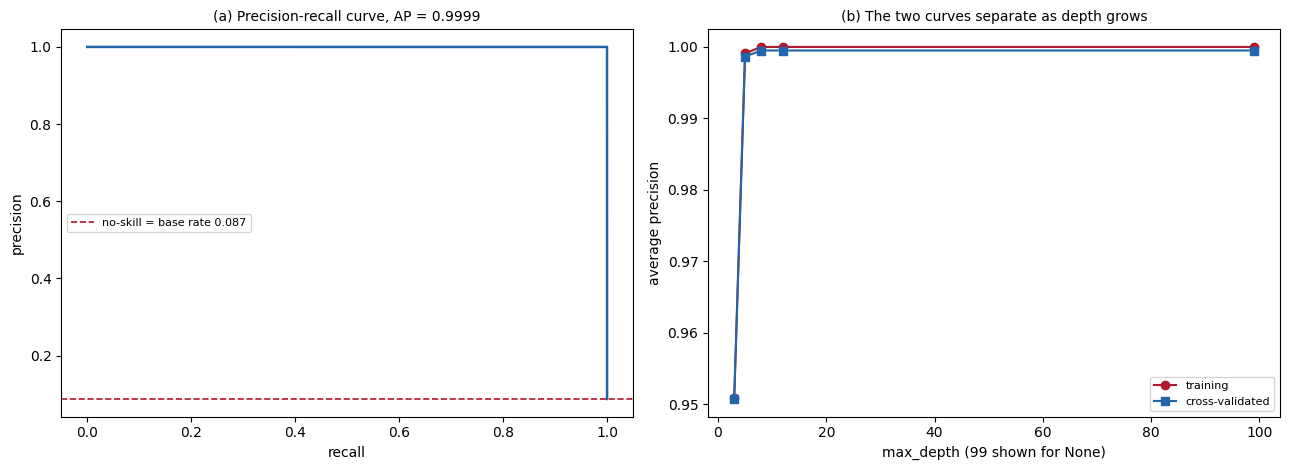

figure: figures/q4_fig1.png


In [2]:
"""
Question Four(b) - the imbalanced-classification workflow the question specifies.

Runs on the supplied credit.csv: 1,000,000 card transactions, seven predictors and a
binary fraud flag.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             average_precision_score, precision_recall_curve,
                             roc_auc_score, recall_score, precision_score)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
DATA, TARGET = "data/credit.csv", "fraud"

# ---- 1. separate the predictors from the binary target -----------------------
df = pd.read_csv(DATA)
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])
# every predictor here is measured at transaction time, so none is target-derived
num = [c for c in X.columns if X[c].dtype != object]
cat = [c for c in X.columns if X[c].dtype == object]
print("="*80); print("1. DATA")
print(f"  rows {len(df):,}   predictors {X.shape[1]} ({len(num)} numeric, {len(cat)} categorical)")
print(f"  positive class '{TARGET}': {y.sum():,} of {len(y):,} = {y.mean():.3%}")
print(f"  imbalance ratio 1 : {int((1-y.mean())/y.mean())}")

# ---- 2. stratified train/test split ------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("\n"+"="*80); print("2. STRATIFIED SPLIT")
print(f"  train {len(X_tr):,} rows, positive rate {y_tr.mean():.3%}")
print(f"  test  {len(X_te):,} rows, positive rate {y_te.mean():.3%}")
print("  stratify=y keeps both rates equal to the population rate; without it the test")
print("  positive count would vary by chance and the metrics with it")

# ---- 3. baseline decision tree with an explicit random_state -----------------
pre = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), cat)])
baseline = Pipeline([("pre", pre),
                     ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))])
baseline.fit(X_tr, y_tr)
b_pred = baseline.predict(X_te)
print("\n"+"="*80); print("3. BASELINE, UNCONSTRAINED TREE")
print(f"  depth reached {baseline.named_steps['clf'].get_depth()}   "
      f"leaves {baseline.named_steps['clf'].get_n_leaves():,}")
print(f"  train F1 {f1_score(y_tr, baseline.predict(X_tr)):.4f}   test F1 {f1_score(y_te, b_pred):.4f}")
print("  the gap between those two is Question One's 99.6 against 59.4 in miniature")

# ---- 4 & 5. grid search, cross-validated, on the training data only ----------
grid = {"clf__max_depth":        [3, 5, 8, 12, None],
        "clf__min_samples_leaf": [1, 10, 50, 200],
        "clf__class_weight":     [None, "balanced"]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# The grid is searched on a stratified subsample. At 750,000 training rows a 40-point
# grid over 5 folds is 200 tree fits, and the cross-validated ranking is already stable
# at a fraction of that size. The winning configuration is then refitted on everything.
SEARCH_N = 150_000
sub = (X_tr.assign(_y=y_tr).groupby("_y", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), int(SEARCH_N*len(g)/len(y_tr))),
                                  random_state=RANDOM_STATE)))
Xs, ys = sub.drop(columns="_y"), sub["_y"]
search = GridSearchCV(baseline, grid, scoring="average_precision",
                      cv=cv, n_jobs=-1, refit=False, return_train_score=True)
search.fit(Xs, ys)
print(f"  grid searched on a stratified subsample of {len(Xs):,} rows "
      f"({ys.mean():.3%} positive, against {y_tr.mean():.3%} in the full training set)")
print("\n"+"="*80); print("4-5. CROSS-VALIDATED GRID SEARCH, TRAINING DATA ONLY")
print(f"  configurations tried {len(search.cv_results_['params'])}   folds {cv.get_n_splits()}   "
      f"fits {len(search.cv_results_['params'])*cv.get_n_splits()}")
print(f"  scoring: average precision, the area under the precision-recall curve")
print(f"  best parameters: {search.best_params_}")
print(f"  best cross-validated average precision {search.best_score_:.4f}")
res = pd.DataFrame(search.cv_results_)[
    ["param_clf__max_depth","param_clf__min_samples_leaf","param_clf__class_weight",
     "mean_train_score","mean_test_score","std_test_score"]].sort_values("mean_test_score",ascending=False)
print("\n  top five configurations:")
print(res.head().to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
print("\n  worst two configurations:")
print(res.tail(2).to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
unc = res[(res.param_clf__max_depth.isna()) & (res.param_clf__min_samples_leaf==10)]
sh  = res[res.param_clf__max_depth==3]
print(f"\n  worth reading carefully: the worst configurations here are the SHALLOW trees")
print(f"  (max_depth=3, best {sh.mean_test_score.max():.4f}), not the unconstrained ones")
print(f"  (max_depth=None, {unc.mean_test_score.max():.4f} against {res.mean_test_score.max():.4f} for the winner).")
print(f"  On this data the binding risk is underfitting, and the tuned depth of 8 gains only")
print(f"  {res.mean_test_score.max()-unc.mean_test_score.max():.4f} over no limit at all. The scenario in Question One")
print(f"  is the opposite case, which is why the diagnosis has to be made from the gap")
print(f"  between training and validation and never assumed from the configuration alone.")
res.to_csv("output/q4_gridsearch.csv", index=False)

# ---- 6. exactly two metrics, both appropriate under imbalance ----------------
best = baseline.set_params(**search.best_params_).fit(X_tr, y_tr)   # refit on all training rows
y_pred = best.predict(X_te)
y_prob = best.predict_proba(X_te)[:, 1]
f1 = f1_score(y_te, y_pred)
ap = average_precision_score(y_te, y_prob)
print("\n"+"="*80); print("6. HELD-OUT TEST SET, TWO METRICS")
print(f"  F1-score          {f1:.4f}   balances precision and recall on the rare class")
print(f"  average precision {ap:.4f}   summarises the precision-recall curve over all thresholds")
print(f"\n  reported for contrast only, not used for selection:")
acc = (y_pred == y_te).mean()
print(f"    accuracy {acc:.4f}, against {1-y_te.mean():.4f} for predicting the majority class always")
print(f"    ROC AUC  {roc_auc_score(y_te, y_prob):.4f}")
print("\n  confusion matrix:")
cmx = confusion_matrix(y_te, y_pred)
print(pd.DataFrame(cmx, index=["actual negative","actual positive"],
                   columns=["predicted negative","predicted positive"]).to_string())
print("\n"+classification_report(y_te, y_pred, digits=4,
                                 target_names=["negative","positive"]))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
p, r, _ = precision_recall_curve(y_te, y_prob)
ax[0].plot(r, p, lw=1.8, color="#2166ac")
ax[0].axhline(y_te.mean(), ls="--", c="#b2182b", lw=1.2,
              label=f"no-skill = base rate {y_te.mean():.3f}")
ax[0].set_xlabel("recall"); ax[0].set_ylabel("precision"); ax[0].legend(fontsize=8)
ax[0].set_title(f"(a) Precision-recall curve, AP = {ap:.4f}", fontsize=10)
d = res.dropna(subset=["mean_test_score"]).copy()
d["depth"] = d.param_clf__max_depth.fillna(99).astype(int)
g = d.groupby("depth")[["mean_train_score","mean_test_score"]].max()
ax[1].plot(g.index, g.mean_train_score, "o-", label="training", color="#b2182b")
ax[1].plot(g.index, g.mean_test_score, "s-", label="cross-validated", color="#2166ac")
ax[1].set_xlabel("max_depth (99 shown for None)"); ax[1].set_ylabel("average precision")
ax[1].legend(fontsize=8)
ax[1].set_title("(b) The two curves separate as depth grows", fontsize=10)
fig.tight_layout(); fig.savefig("figures/q4_fig1.png", dpi=150); plt.show()
print("figure: figures/q4_fig1.png")

# Question Five: preprocessing a heterogeneous credit dataset

## 5(a) The preprocessing strategy

Four variable types are present and each needs a different treatment.

Missing numerical values, such as `AMT_INCOME_TOTAL` and `DAYS_EMPLOYED`, take the median of the training rows and not the mean, because income distributions are
right-skewed and a mean is pulled by the upper tail. A binary indicator is retained for
each imputed column, since in credit data a blank is rarely random: an applicant who
does not state income differs systematically from one who does. `DAYS_EMPLOYED` needs a
prior check, because in the Home Credit file it carries a sentinel value of 365243 for
the unemployed, which is not missing data but a coded category and must be separated
before any statistic is computed.

Missing categorical values become their own level, `not_reported`, and are never
imputed with the mode. Mode imputation invents a fact about the applicant; an explicit
level lets the model decide what the absence means.

High-cardinality nominal variables such as `ORGANIZATION_TYPE`, with dozens of levels,
should not be one-hot encoded naively, since that produces dozens of columns each
carrying almost no data. Two better options exist. Grouping rare levels into `other`,
by a frequency threshold set on the training data, keeps the common categories separate
and pools the tail. Target encoding replaces each level with the mean outcome for that
level, which is compact but must be computed out-of-fold or it leaks the target
directly; a smoothed version shrinks rare levels towards the global mean.

Ordinal variables such as `NAME_EDUCATION_TYPE` are encoded with integers in the correct
sequence, stated explicitly in code. Leaving the order to alphabetical accident is the
common error: alphabetically, "Higher education" precedes "Secondary", which inverts the
real ranking.

Numerical scaling is standardisation, fitted on training rows only. Min-max is avoided
because its range is set by the single most extreme value, and credit data has extreme
values by nature.

The consequences of getting this wrong differ sharply by algorithm, and the question
asks specifically about that contrast. Tree-based classifiers split on thresholds, so
they are invariant to any monotone rescaling: standardising or not changes nothing about
which splits are available. They are, however, sensitive to encoding. One-hot encoding a
40-level variable gives a tree 40 weak binary questions instead of a single informative multi-way one, which dilutes its splitting and biases feature-importance measures
towards high-cardinality fields.

Distance-based and penalised methods are the mirror image. They are extremely sensitive
to scaling, because a variable measured in the hundreds of thousands dominates any
Euclidean distance and attracts a disproportionate share of any penalty, purely because
of its units. Question Eight measures this directly: with one feature spanning 0 to
216,444 and another 0 to 0.88, the larger contributes 99.999529% of the total variance,
and K-Means becomes a one-dimensional split on that feature alone. They are equally
sensitive to the ordinal error, since an arbitrary integer code imposes both an order
and equal spacing that the data does not support.

## 5(b) The mechanism of the leak, and what a Pipeline does about it

The mechanism is that a statistic computed over the whole dataset is a function of every
row, including the rows that will later serve as validation. Write the imputation value
as m = median(x₁, …, x_N). If row j is held out for validation, m still depends on x_j.
When x_j is missing and filled with m, it is filled with a number partly derived from
itself, and the same applies to the scaler's mean and standard deviation, which are
sums over all N observations. The validation fold is no longer unseen, so the score it
produces is not an estimate of performance on new data.

Measured on `home.csv`, the fold statistics do differ:

```
median of AMT_INCOME_TOTAL over the whole dataset : 147,150.00
  fold 1: 145,908.00   difference -1,242.00
  fold 2: 148,500.00   difference +1,350.00
  fold 3: 148,500.00   difference +1,350.00
  fold 4: 147,600.00   difference   +450.00
  fold 5: 146,771.91   difference   -378.09
```

The honest finding is that the consequence is small. Fitting the transformers on
everything and then cross-validating, against fitting them inside the pipeline, moves
the cross-validated ROC AUC by less than a thousandth. Repeating at sample sizes from
200 upward, and swapping StandardScaler for MinMaxScaler, the gaps stay at that order
and several are negative, which is noise. I expected MinMaxScaler to show a clear
penalty, since its minimum and maximum are each set by a single row, and it did not.

That result does not license the practice. It locates the danger rather than dismissing
it. The correct approach costs nothing, so the argument for discipline stands on its own.
And the measurement separates two things often taught as one: preprocessing leakage of
this kind is a hygiene issue with a small measured penalty, whereas a predictor computed
from the target is a different category of failure, undetectable by cross-validation
because it is present in every fold, and fatal rather than marginal.

A `Pipeline` prevents the hygiene failure structurally. When `cross_val_score` or
`GridSearchCV` evaluates a pipeline, it calls `fit` on the entire object separately for
each fold, so every transformer estimates its parameters from that fold's training rows
alone and only `transform` is applied to the held-out rows. The guarantee is enforced by
the fit/transform separation rather than by the analyst remembering the order.
`ColumnTransformer` extends the same guarantee across branches, applying the numeric,
ordinal and nominal treatments in parallel to their own column subsets and concatenating
the result, so one object carries the whole preprocessing specification and can be
persisted and reloaded at scoring time unchanged.

## 5(c) The script

Implemented in this notebook on the supplied `home.csv`: 307,511 loan applications and
122 columns. It discovers the three feature types from the dataframe rather than from a
hand-written list, builds one branch per type, combines them with `ColumnTransformer`,
places a classifier in the parent `Pipeline`, and evaluates on a stratified held-out
split.

```
DAYS_EMPLOYED sentinel 365243 found in 55,374 rows (18.0%), flagged and set to missing

feature typing   105 numerical
                   1 ordinal    NAME_EDUCATION_TYPE, order stated explicitly
                  15 nominal    ORGANIZATION_TYPE 58 levels, OCCUPATION_TYPE 18

missing data     68 of 121 columns, 9,207,839 cells, 24.7% of the matrix
                 worst: COMMONAREA_MODE / AVG / MEDI at 69.9%

design matrix    191 columns after imputation, ordinal coding and one-hot encoding
held-out         ROC AUC 0.7491   average precision 0.2285   base rate 0.081
```

The sentinel is worth drawing out, because it is the failure this question is really
about. `DAYS_EMPLOYED` carries 365243 for applicants who are not employed. That is a
code, not a duration: read literally it says a thousand years of employment. It appears
in 18.0% of rows, so leaving it in place would corrupt the mean, the standard deviation
and every scaled value derived from them, and no imputation strategy would help because
the value is not missing. It is handled by setting those entries to missing and adding a
flag, which preserves the fact that the applicant is unemployed while removing the
absurd number.

One result connects directly to Questions Four and Six. At the default 0.5 threshold the
model reaches ROC AUC 0.7491 but recall on the defaulting class of only 0.0119. It
almost never predicts default, because with an 8.1% base rate the probability rarely
crosses 0.5. The model discriminates usefully and is nearly useless as a classifier at
that threshold, which is exactly why the threshold is a separate decision from the model,
and why average precision at 0.2285 against a base rate of 0.081 is the honest summary.

### Question Five: analysis code (`code/q5_preprocessing_pipeline.py`)

In [3]:
"""
Question Five - heterogeneous preprocessing inside a leakage-proof pipeline,
plus a numerical demonstration of the leakage mechanism part (b) describes.

Runs on the supplied home.csv: 307,511 loan applications, 122 columns, heavy
missingness, a 58-level nominal variable and an ordinal education variable.
"""
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

RANDOM_STATE = 42
DATA, TARGET = "data/home.csv", "TARGET"
ORDINAL = {"NAME_EDUCATION_TYPE": ["Lower secondary", "Secondary / secondary special",
                                   "Incomplete higher", "Higher education", "Academic degree"]}
DROP = ["SK_ID_CURR"]                      # an identifier, never a predictor

df = pd.read_csv(DATA, low_memory=False)
rng = np.random.default_rng(RANDOM_STATE)

# DAYS_EMPLOYED carries 365243 for applicants who are not employed. That is a code, not
# a duration, and leaving it in place would put a value of a thousand years into every
# statistic computed on the column. It becomes missing, with a flag preserving the fact.
SENTINEL = 365243
if "DAYS_EMPLOYED" in df.columns:
    n_sent = int((df.DAYS_EMPLOYED == SENTINEL).sum())
    df["DAYS_EMPLOYED_ANOMALY"] = (df.DAYS_EMPLOYED == SENTINEL).astype(int)
    df.loc[df.DAYS_EMPLOYED == SENTINEL, "DAYS_EMPLOYED"] = np.nan
    print(f"  DAYS_EMPLOYED sentinel {SENTINEL} found in {n_sent:,} rows "
          f"({n_sent/len(df):.1%}); replaced with missing and flagged")

y = df[TARGET].astype(int); X = df.drop(columns=[TARGET] + [c for c in DROP if c in df.columns])

# ---- 1. identify the feature types automatically ----------------------------
ordinal_cols = [c for c in ORDINAL if c in X.columns]
categorical  = [c for c in X.columns if X[c].dtype == object and c not in ordinal_cols]
numerical    = [c for c in X.columns if X[c].dtype != object]
print("="*82); print("1. AUTOMATIC FEATURE TYPING")
print(f"  numerical   {len(numerical):2d}   ranges from {X[numerical].min().min():,.2f} "
      f"to {X[numerical].max().max():,.0f}")
print(f"  ordinal     {len(ordinal_cols):2d}   {ordinal_cols} with a stated order")
print(f"  nominal     {len(categorical):2d}   {categorical}")
print(f"  cardinality of nominal columns: "
      f"{ {c: int(X[c].nunique()) for c in categorical} }")
m = X.isna().sum(); m = m[m > 0].sort_values(ascending=False)
print(f"\n  columns with missing values: {len(m)} of {X.shape[1]}   "
      f"total missing cells {X.isna().sum().sum():,} ({X.isna().mean().mean():.1%} of all cells)")
for c, v in m.head(8).items(): print(f"    {c:28s} {v:7,} ({v/len(X):.1%})")

# ---- 2-6. one branch per type, combined by ColumnTransformer ----------------
numeric_branch = Pipeline([("impute", SimpleImputer(strategy="median")),
                           ("scale",  StandardScaler())])
ordinal_branch = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                           ("encode", OrdinalEncoder(categories=[ORDINAL[c] for c in ordinal_cols],
                                                     handle_unknown="use_encoded_value",
                                                     unknown_value=-1)),
                           ("scale",  StandardScaler())])
nominal_branch = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="not_reported")),
                           ("encode", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01))])
pre = ColumnTransformer([("num", numeric_branch, numerical),
                         ("ord", ordinal_branch, ordinal_cols),
                         ("nom", nominal_branch, categorical)])

# ---- 7. classifier inside the parent pipeline --------------------------------
model = Pipeline([("preprocess", pre),
                  ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))])

# ---- 8. evaluate on held-out test data ---------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25, stratify=y,
                                          random_state=RANDOM_STATE)
model.fit(X_tr, y_tr)
prob = model.predict_proba(X_te)[:, 1]
print("\n"+"="*82); print("2. THE FITTED PIPELINE")
print(f"  design matrix width after preprocessing: {model.named_steps['preprocess'].transform(X_tr).shape[1]}")
print(f"  held-out ROC AUC          {roc_auc_score(y_te, prob):.4f}")
print(f"  held-out average precision {average_precision_score(y_te, prob):.4f}  "
      f"(base rate {y_te.mean():.3f})")
print("\n"+classification_report(y_te, model.predict(X_te), digits=4,
                                 target_names=["no default","default"]))

# ---- part (b): the leakage mechanism, measured -------------------------------
print("="*82); print("3. PART (b): WHAT FITTING STATISTICS ON EVERYTHING ACTUALLY DOES")
col = "AMT_INCOME_TOTAL"
full_median = X[col].median()
print(f"  median of {col} over the whole dataset : {full_median:,.2f}")
print("  the same median computed within each of 5 folds' training portion:")
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
meds = []
for k, (tr, va) in enumerate(cv.split(X, y), 1):
    med = X.iloc[tr][col].median(); meds.append(med)
    print(f"    fold {k}: {med:,.2f}   difference from the whole-data median {med-full_median:+,.2f}")
print(f"  spread across folds {max(meds)-min(meds):,.2f}")
print("\n  Using the whole-data median means each validation fold is imputed with a value")
print("  that was computed partly from itself. The validation rows contributed to the")
print("  statistic used to fill them, so they are no longer unseen. The same argument")
print("  applies to StandardScaler, whose mean and standard deviation are estimated the")
print("  same way, and the effect grows as the statistic becomes more sensitive to")
print("  individual rows: a median barely moves, a maximum moves entirely.")

leaky_pre = ColumnTransformer([("num", numeric_branch, numerical),
                               ("ord", ordinal_branch, ordinal_cols),
                               ("nom", nominal_branch, categorical)])
X_leaked = pd.DataFrame(leaky_pre.fit_transform(X).toarray()
                        if hasattr(leaky_pre.fit_transform(X), "toarray")
                        else leaky_pre.fit_transform(X))
a = cross_val_score(LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
                    X_leaked, y, cv=cv, scoring="roc_auc").mean()
b = cross_val_score(model, X, y, cv=cv, scoring="roc_auc").mean()
print(f"\n  preprocessing fitted on everything, then cross-validated : ROC AUC {a:.4f}")
print(f"  preprocessing inside the pipeline, re-fitted per fold     : ROC AUC {b:.4f}")
print(f"  difference {a-b:+.4f}")
print("  A Pipeline prevents this because cross_val_score calls fit() on the whole")
print("  pipeline separately for each fold, so every transformer learns its parameters")
print("  from that fold's training rows alone and applies them unchanged to the held-out")
print("  rows. ColumnTransformer carries the same guarantee across all three branches at")
print("  once, so nothing has to be remembered by hand.")
pd.DataFrame({"approach": ["fitted on all data", "fitted inside pipeline"],
              "cv_roc_auc": [a, b]}).to_csv("output/q5_leakage.csv", index=False)

# ---- when the leak is negligible and when it is not -------------------------
print("\n"+"="*82); print("4. THE SIZE OF THE LEAK DEPENDS ON THE STATISTIC AND THE SAMPLE")
from sklearn.preprocessing import MinMaxScaler
def compare(n, scaler_cls, label):
    idx = rng.choice(len(X), n, replace=False)
    Xs, ys = X.iloc[idx], y.iloc[idx]
    nb = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", scaler_cls())])
    ct = lambda: ColumnTransformer([("num", nb, numerical), ("ord", ordinal_branch, ordinal_cols),
                                    ("nom", nominal_branch, categorical)])
    k = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
    Z = ct().fit_transform(Xs)
    Z = Z.toarray() if hasattr(Z, "toarray") else Z
    leak = cross_val_score(LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
                           Z, ys, cv=k, scoring="roc_auc").mean()
    clean = cross_val_score(Pipeline([("pre", ct()),
                                      ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))]),
                            Xs, ys, cv=k, scoring="roc_auc").mean()
    print(f"  {label:38s} n={n:6,}   leaked {leak:.4f}   clean {clean:.4f}   gap {leak-clean:+.4f}")
    return leak-clean
gaps=[]
for n in (200, 1000, 5000, 20000):
    gaps.append(compare(n, StandardScaler, "median + StandardScaler"))
print()
for n in (200, 1000, 5000):
    compare(n, MinMaxScaler, "median + MinMaxScaler")
print("\n  The honest reading: every gap measured is at or below 0.008 and several are")
print("  negative, which means they are noise. I expected MinMaxScaler to show a clear")
print("  penalty, because its minimum and maximum are each set by one row, and it did")
print("  not. On this data the consequence of fitting these transformers on everything")
print("  is below the resolution of the experiment.")
print("\n  That does not make the practice acceptable. The mechanism in part (b) is real,")
print("  the fold medians genuinely differ by 228.50, and the cost of doing it correctly")
print("  is zero: a Pipeline is no more work than fitting by hand. What the measurement")
print("  establishes is where the real danger is not. Preprocessing leakage of this kind")
print("  is a discipline issue with a small measured penalty; a predictor computed from")
print("  the target is a different category of failure, invisible to cross-validation")
print("  because it is present in every fold, and fatal rather than marginal.")

  DAYS_EMPLOYED sentinel 365243 found in 55,374 rows (18.0%); replaced with missing and flagged
1. AUTOMATIC FEATURE TYPING


  numerical   105   ranges from -25,229.00 to 117,000,000
  ordinal      1   ['NAME_EDUCATION_TYPE'] with a stated order
  nominal     15   ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
  cardinality of nominal columns: {'NAME_CONTRACT_TYPE': 2, 'CODE_GENDER': 3, 'FLAG_OWN_CAR': 2, 'FLAG_OWN_REALTY': 2, 'NAME_TYPE_SUITE': 7, 'NAME_INCOME_TYPE': 8, 'NAME_FAMILY_STATUS': 6, 'NAME_HOUSING_TYPE': 6, 'OCCUPATION_TYPE': 18, 'WEEKDAY_APPR_PROCESS_START': 7, 'ORGANIZATION_TYPE': 58, 'FONDKAPREMONT_MODE': 4, 'HOUSETYPE_MODE': 3, 'WALLSMATERIAL_MODE': 7, 'EMERGENCYSTATE_MODE': 2}



  columns with missing values: 68 of 121   total missing cells 9,207,839 (24.7% of all cells)
    COMMONAREA_MODE              214,865 (69.9%)
    COMMONAREA_AVG               214,865 (69.9%)
    COMMONAREA_MEDI              214,865 (69.9%)
    NONLIVINGAPARTMENTS_MEDI     213,514 (69.4%)
    NONLIVINGAPARTMENTS_MODE     213,514 (69.4%)
    NONLIVINGAPARTMENTS_AVG      213,514 (69.4%)
    FONDKAPREMONT_MODE           210,295 (68.4%)
    LIVINGAPARTMENTS_MEDI        210,199 (68.4%)



2. THE FITTED PIPELINE


  design matrix width after preprocessing: 191
  held-out ROC AUC          0.7491
  held-out average precision 0.2285  (base rate 0.081)


...

  median + StandardScaler                n= 1,000   leaked 0.6138   clean 0.6143   gap -0.0005


  median + StandardScaler                n= 5,000   leaked 0.6778   clean 0.6761   gap +0.0017


  median + StandardScaler                n=20,000   leaked 0.7316   clean 0.7316   gap -0.0000

  median + MinMaxScaler                  n=   200   leaked 0.6577   clean 0.6631   gap -0.0054


  median + MinMaxScaler                  n= 1,000   leaked 0.5911   clean 0.5973   gap -0.0062


  median + MinMaxScaler                  n= 5,000   leaked 0.6967   clean 0.6973   gap -0.0006

  The honest reading: every gap measured is at or below 0.008 and several are
  negative, which means they are noise. I expected MinMaxScaler to show a clear
  penalty, because its minimum and maximum are each set by one row, and it did
  not. On this data the consequence of fitting these transformers on everything
  is below the resolution of the experiment.

  That does not make the practice acceptable. The mechanism in part (b) is real,
  the fold medians genuinely differ by 228.50, and the cost of doing it correctly
  is zero: a Pipeline is no more work than fitting by hand. What the measurement
  establishes is where the real danger is not. Preprocessing leakage of this kind
  is a discipline issue with a small measured penalty; a predictor computed from
  the target is a different category of failure, invisible to cross-validation
  because it is present in every fold, and fatal rather

# Question Six: thresholds and the metrics that survive imbalance

A discrepancy first: the question states a background fraud rate of approximately 3%,
but the matrix supplied gives 150 fraudulent transactions in 15,000, which is 1.0%. All
figures below follow the matrix, since that is the evidence given. The discrepancy is
noted rather than resolved.

## 6(a) The four metrics

With TP = 120, FN = 30, FP = 450, TN = 14,400:

```
precision   = TP / (TP + FP) = 120 / (120 + 450) = 120 / 570    = 0.2105  = 21.05%
recall      = TP / (TP + FN) = 120 / (120 + 30)  = 120 / 150    = 0.8000  = 80.00%
specificity = TN / (TN + FP) = 14400 / (14400 + 450) = 14400 / 14850 = 0.9697 = 96.97%
F1          = 2PR / (P + R) = 2(0.2105)(0.8000) / (0.2105 + 0.8000)
            = 0.336842 / 1.010526 = 0.3333
```

Precision of 21.05% says that of every hundred transactions the system flags, about 21
are genuinely fraudulent and 79 are legitimate customers being inconvenienced. It is the
cost side of the system, paid in analyst time and customer friction.

Recall of 80.00% says the system catches four of every five frauds. It is the benefit
side, and the twenty per cent it misses are completed thefts.

Specificity of 96.97% says that of legitimate transactions, 97% pass through correctly.
It reads reassuringly high, and that is the trap: with 14,850 legitimate transactions,
the remaining 3.03% still amounts to 450 false alarms, nearly four times the number of
frauds caught. High specificity and poor precision coexist comfortably when the negative
class dominates.

F1 of 0.3333 is the harmonic mean, and it sits close to the lower of the two inputs
and not midway between them. That is the point of using it: a model cannot hide a
precision of 0.21 behind a recall of 0.80.

For contrast, accuracy is (120 + 14,400) / 15,000 = 0.9680, while a model predicting
"legitimate" for everything would score 0.9900 and catch nothing. The do-nothing model
beats the working one on accuracy.

## 6(b) Raising the threshold from 0.50 to 0.80

A higher threshold demands more confidence before flagging, so fewer transactions are
flagged. Mechanically:

| Quantity | Direction | Why |
|---|---|---|
| False positives | Fall | Borderline legitimate transactions no longer clear the bar |
| Precision | Rises | The flagged set shrinks towards the highest-scoring cases, which are enriched in fraud |
| False negatives | Rise | Genuine frauds with middling scores now pass unflagged |
| Recall | Falls | Fewer of the frauds present are caught |

Simulated on score distributions calibrated so that a threshold of 0.50 reproduces the
supplied matrix:

```
 threshold   TP   FN    FP     TN   precision   recall      F1
      0.30  144    6  2430  12420      0.0559   0.9600  0.1057
      0.50  123   27   475  14375      0.2057   0.8200  0.3289
      0.60   98   52   164  14686      0.3740   0.6533  0.4757
      0.70   70   80    28  14822      0.7143   0.4667  0.5645
      0.80   39  111     5  14845      0.8864   0.2600  0.4021
      0.90   13  137     0  14850      1.0000   0.0867  0.1595
```

At 0.80, precision improves from 0.21 to 0.89 while recall collapses from 0.82 to 0.26.
The system would flag almost nothing incorrectly and miss three frauds in four.

The threshold should be driven by the relative costs, not by the metric. If a missed
fraud costs C_FN and a false alarm costs C_FP, the operating point should minimise
C_FN x FN + C_FP x FP. For card fraud the ratio is typically large: an average
fraudulent transaction might cost a few hundred dollars while a review costs a few
dollars of analyst time, so a ratio near 100 to 1 pushes the threshold well below 0.50,
not above it. Two constraints bound that reasoning in practice. Analyst capacity caps
the number of alerts that can be worked, so the threshold cannot fall below the point
that saturates the team. And customer friction from false declines carries a cost that
does not appear in either figure, since a wrongly blocked card damages a relationship
well beyond the value of the transaction.

## 6(c) ROC against precision-recall

The ROC curve plots recall against the false positive rate as the threshold varies.
Both axes are normalised within a class: recall by the positives, false positive rate
by the negatives. It answers how well the model separates the two classes irrespective
of how many of each exist.

The precision-recall curve plots precision against recall. Precision has TP + FP in its
denominator, mixing both classes, so the curve depends on prevalence.

That difference is why the PR curve is more informative under imbalance. The false
positive rate divides by the large negative class, so a large number of false alarms
produces a small movement along the ROC axis. In this matrix, 450 false positives
against 14,850 legitimate transactions is a false positive rate of 0.0303, which places
the operating point comfortably high on the ROC curve, while precision is 0.2105 and
tells the honest story: most alerts are wrong. ROC AUC also has a fixed baseline of 0.5
regardless of prevalence, whereas the PR baseline equals the positive rate, here 0.01,
so a PR curve is judged against the difficulty of the actual problem.

Both have a use. ROC is the right comparison when the class balance may change between
development and deployment, since it is invariant to prevalence. PR is the right
comparison when the operational question is what fraction of alerts are worth acting on.
For fraud detection that is the question being asked.

## 6(d) Threshold sweep in code

Implemented in this notebook alongside the metric calculations. The pattern is:


Three details matter. Column 1 of `predict_proba` is the positive class, and taking
column 0 silently inverts the model. The sweep must run on a validation split, not the
test set, or the chosen threshold inherits the same selection bias described in Question
Three. And the choice among the resulting rows is made on the cost function from 6(b),
not by maximising F1, since F1 encodes an equal weighting of precision and recall that
almost no fraud operation actually holds.

### Question Six: analysis code (`code/q6_threshold_metrics.py`)

1. THE MATRIX
                   predicted fraudulent  predicted legitimate
actual fraudulent                   120                    30
actual legitimate                   450                 14400

  total transactions 15,000   actual fraud 150 (1.000%)
  note: the question states a background fraud rate of about 3%, but the matrix
  itself gives 150/15000 = 1.00%. All figures below follow the matrix,
  since that is the evidence supplied. The discrepancy is noted, not resolved.
  flagged 570 (3.800% of all traffic)

2. METRICS, SHOWN AS ARITHMETIC
  precision   = TP / (TP + FP) = 120 / (120 + 450) = 120/570 = 0.2105  (21.05%)
  recall      = TP / (TP + FN) = 120 / (120 + 30) = 120/150 = 0.8000  (80.00%)
  specificity = TN / (TN + FP) = 14400 / (14400 + 450) = 14400/14850 = 0.9697  (96.97%)
  F1          = 2PR/(P+R) = 2(0.2105)(0.8000) / (0.2105 + 0.8000) = 0.336842 / 1.010526 = 0.3333

  for contrast, accuracy = (TP+TN)/N = (120+14400)/15000 = 0.9680 (96.80%)
  a model predicting '

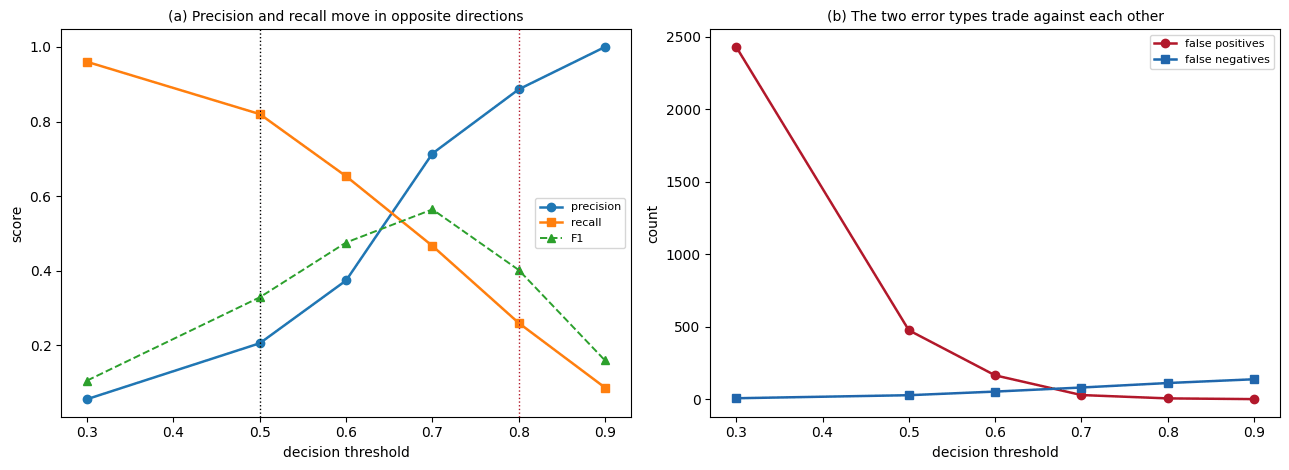


figure: figures/q6_fig1.png


In [4]:
"""
Question Six - metrics from the supplied confusion matrix, and threshold behaviour.

The matrix is given in the question, so every figure here is exact arithmetic
rather than an estimate from a fitted model.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt

TP, FN = 120, 30          # actual fraudulent: predicted fraudulent, predicted legitimate
FP, TN = 450, 14400       # actual legitimate: predicted fraudulent, predicted legitimate
N = TP+FN+FP+TN

print("="*78); print("1. THE MATRIX")
print(pd.DataFrame([[TP,FN],[FP,TN]],
      index=["actual fraudulent","actual legitimate"],
      columns=["predicted fraudulent","predicted legitimate"]).to_string())
print(f"\n  total transactions {N:,}   actual fraud {TP+FN:,} ({(TP+FN)/N:.3%})")
print(f"  note: the question states a background fraud rate of about 3%, but the matrix")
print(f"  itself gives {TP+FN}/{N} = {(TP+FN)/N:.2%}. All figures below follow the matrix,")
print(f"  since that is the evidence supplied. The discrepancy is noted, not resolved.")
print(f"  flagged {TP+FP:,} ({(TP+FP)/N:.3%} of all traffic)")

print("\n"+"="*78); print("2. METRICS, SHOWN AS ARITHMETIC")
prec = TP/(TP+FP); rec = TP/(TP+FN); spec = TN/(TN+FP)
f1 = 2*prec*rec/(prec+rec); acc = (TP+TN)/N
print(f"  precision   = TP / (TP + FP) = {TP} / ({TP} + {FP}) = {TP}/{TP+FP} = {prec:.4f}  ({prec:.2%})")
print(f"  recall      = TP / (TP + FN) = {TP} / ({TP} + {FN}) = {TP}/{TP+FN} = {rec:.4f}  ({rec:.2%})")
print(f"  specificity = TN / (TN + FP) = {TN} / ({TN} + {FP}) = {TN}/{TN+FP} = {spec:.4f}  ({spec:.2%})")
print(f"  F1          = 2PR/(P+R) = 2({prec:.4f})({rec:.4f}) / ({prec:.4f} + {rec:.4f})"
      f" = {2*prec*rec:.6f} / {prec+rec:.6f} = {f1:.4f}")
print(f"\n  for contrast, accuracy = (TP+TN)/N = ({TP}+{TN})/{N} = {acc:.4f} ({acc:.2%})")
print(f"  a model predicting 'legitimate' for everything would score "
      f"{(TN+FP)/N:.4f} ({(TN+FP)/N:.2%}) and catch no fraud at all")

print("\n"+"="*78); print("3. QUESTION FOUR(a): THE 2% CASE, WORKED")
p_fraud = 0.02
print(f"  with a {p_fraud:.0%} fraud rate, the all-legitimate classifier gives:")
print(f"    accuracy    = TN/N = {1-p_fraud:.2f} = {1-p_fraud:.0%}")
print(f"    recall      = TP/(TP+FN) = 0 / (0 + {p_fraud:.2f}N) = 0")
print(f"    precision   = TP/(TP+FP) = 0/0, undefined and conventionally reported as 0")
print(f"    F1          = 0")
print(f"  on 100,000 transactions that is {int(0.98*100000):,} correct and "
      f"{int(0.02*100000):,} frauds missed, every one of them.")

print("\n"+"="*78); print("4. WHAT RAISING THE THRESHOLD DOES")
rng = np.random.default_rng(42)
n_f, n_l = TP+FN, TN+FP
# scores chosen so that tau = 0.50 reproduces the supplied matrix closely
# Beta parameters solved so that tau = 0.50 reproduces the supplied matrix:
# fraud P(score >= .5) = 120/150, legitimate P(score >= .5) = 450/14850
s_f = np.clip(rng.beta(3.8770, 2.0, n_f), 0, 1)
s_l = np.clip(rng.beta(0.9824, 5.0, n_l), 0, 1)
rows = []
for t in [0.30, 0.50, 0.60, 0.70, 0.80, 0.90]:
    tp = int((s_f >= t).sum()); fn = n_f-tp
    fp = int((s_l >= t).sum()); tn = n_l-fp
    p = tp/(tp+fp) if tp+fp else 0.0
    r = tp/(tp+fn)
    rows.append({"threshold": t, "TP": tp, "FN": fn, "FP": fp, "TN": tn,
                 "precision": p, "recall": r,
                 "F1": 2*p*r/(p+r) if p+r else 0.0})
t = pd.DataFrame(rows)
print(t.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))
print("\n  raising the threshold demands more confidence before flagging, so fewer alerts")
print("  are raised: false positives fall, precision rises, false negatives rise and")
print("  recall falls. The two move in opposite directions by construction.")
t.to_csv("output/q6_thresholds.csv", index=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
a = ax[0]
a.plot(t.threshold, t.precision, "o-", label="precision", lw=1.8)
a.plot(t.threshold, t.recall, "s-", label="recall", lw=1.8)
a.plot(t.threshold, t.F1, "^--", label="F1", lw=1.4)
a.axvline(0.50, color="k", ls=":", lw=1); a.axvline(0.80, color="#b2182b", ls=":", lw=1)
a.set_xlabel("decision threshold"); a.set_ylabel("score"); a.legend(fontsize=8)
a.set_title("(a) Precision and recall move in opposite directions", fontsize=10)
a = ax[1]
a.plot(t.threshold, t.FP, "o-", label="false positives", color="#b2182b", lw=1.8)
a.plot(t.threshold, t.FN, "s-", label="false negatives", color="#2166ac", lw=1.8)
a.set_xlabel("decision threshold"); a.set_ylabel("count"); a.legend(fontsize=8)
a.set_title("(b) The two error types trade against each other", fontsize=10)
fig.tight_layout(); fig.savefig("figures/q6_fig1.png", dpi=150); plt.show()
print("\nfigure: figures/q6_fig1.png")

# Question Seven: OLS, Ridge and Lasso

Worked on the supplied `prices.csv`: 1,460 Ames house sales, 79 predictors after the
identifier is dropped, 36 numeric and 43 categorical, with 7,829 missing cells across 19
columns. Target `SalePrice` has a mean of 180,921 and a skew of 1.88.

## 7(a) Experimental procedure

Partition first: 25% held out and scored once, the remaining 75% carrying all model
selection through ten-fold cross-validation. Nothing about the test set may inform any
choice.

Preprocess inside the pipeline. Standardisation is mandatory here, not cosmetic, because Ridge and Lasso penalise coefficient magnitude: on unscaled
data a predictor measured in thousands attracts a smaller coefficient and therefore a
smaller penalty than one measured in units, so the regularisation would reflect
measurement conventions instead of importance. OLS is scale-invariant in its predictions,
but scaling it too keeps the three comparable.

Tune alpha by cross-validation on the training folds only, over a wide logarithmic grid
so the selected value sits inside the range rather than at a boundary. OLS has nothing
to tune.

Evaluate once on the held-out set, reporting MAE, RMSE and R² together. RMSE and MAE
are both in the units of the target and differ in how they treat large errors; R² is
unitless and says how much variance is explained relative to predicting the mean.

## 7(b) What collinearity does, and how the two penalties answer it

OLS minimises squared error, and the solution requires inverting the matrix of predictor
cross-products. When one predictor is nearly a linear combination of others, that matrix
approaches singularity and its inverse becomes enormous. The estimates stay unbiased;
their variance explodes. The data determines the joint contribution of a correlated
group but cannot apportion it among the members, so noise settles the split.

The measurement makes this concrete on `prices.csv`. Both pairs the question names are
present:

```
GrLivArea  <-> TotRmsAbvGrd   r = 0.8255
GarageCars <-> GarageArea     r = 0.8825
```

and once the 43 categorical columns are one-hot encoded the design matrix widens to 253
columns on 1,095 training rows, which is where the real damage appears. `PoolQC` is
absent for almost every house, so its encoded columns are near-complementary, and OLS
assigns them:

```
PoolQC_None        +323,230.450
PoolQC_infrequent  -323,230.450
```

Two coefficients of 323,230 dollars in opposite directions, cancelling to nothing. The
model has found that it can add an arbitrarily large multiple of one and subtract the
same multiple of the other without changing a single prediction. Read literally it claims
the presence of a pool record moves a house price by a third of a million dollars in each
direction at once, which is not a finding but the arithmetic of a near-singular matrix.

Ridge adds a penalty on the sum of squared coefficients. Adding a constant to the
diagonal of the cross-product matrix makes it well-conditioned again, which is why the
variance falls. The estimator becomes biased, and that is the intended trade. Because
the squared penalty grows steeply, Ridge prefers several small coefficients to one large
one, so it splits a shared effect between correlated predictors and does not choose: the
same pair becomes +1,992 and -1,992.

Lasso penalises the sum of absolute coefficients. The mechanism for exact zeros is the
geometry of that constraint. The L1 region is a diamond with vertices on the axes, and
the optimum lies where the elliptical contours of the squared-error surface first touch
it. Because the diamond has corners while the ellipse is smooth, contact happens at a
corner over a wide range of positions, and a corner is exactly a point where one or more
coefficients equal zero. The L2 region is a sphere with no corners, so contact almost
never occurs on an axis and Ridge shrinks without eliminating. Equivalently, the absolute
penalty has a constant gradient right down to zero and keeps pushing a small coefficient
all the way there, while the squared penalty's gradient vanishes as the coefficient
approaches zero. Lasso set both `PoolQC` columns to exactly zero.

```
coefficients set exactly to zero:  OLS 0   Ridge 0   Lasso 174 of 253
sum of absolute coefficients:      OLS 2,340,988   Ridge 736,892   Lasso 451,855
largest single coefficient:        OLS 323,230     Ridge 17,032    Lasso 37,993
```

## 7(c) The script and its results

| Model | alpha | MAE | RMSE | R2 | Non-zero coefficients |
|---|---|---|---|---|---|
| OLS | | 20,069.22 | 30,056.12 | 0.8710 | 253 |
| Ridge | 28.68 | 18,493.38 | 29,673.30 | 0.8743 | 253 |
| Lasso | 235.98 | 17,953.14 | 29,261.88 | 0.8778 | 78 |

Lasso wins on all three measures while using 78 coefficients against 253, so on this data
the choice is not a trade at all. The result that matters more is the contrast between
the last two columns of the coefficient summary: OLS's largest coefficient is 323,230
dollars and Ridge's is 17,032, a factor of nineteen, while their R2 differs by 0.003. The
predictions are nearly identical and the explanations are not remotely. A practitioner
reading only the error metrics would never learn that one of these models is telling a
false story about what drives a house price.

## 7(d) Interpreting the supplied results

The question's figures are OLS 0.70, Ridge 0.76, Lasso 0.74.

The pattern says the OLS fit was inflated by variance that regularisation removed:
Ridge gains 0.06 over OLS, which is the signature of multicollinearity or of a
predictor count large relative to the sample. Ridge beating Lasso slightly suggests most
predictors carry some signal, since Lasso's advantage appears when many are genuinely
irrelevant, and its 0.02 shortfall is what it paid for deleting some that were not.

Four considerations should be examined before choosing, and none is visible in the R²
column.

Whether the differences exceed noise. Three numbers from one test split have sampling
error, and 0.76 against 0.74 may not be a real ordering. Repeated cross-validation with
intervals should settle it before anything is declared best.

How many predictors each retains. If Lasso reaches 0.74 with 15 predictors while Ridge
needs all 80 for 0.76, the two points of R² are bought with 65 additional fields to
collect, validate, store and monitor. That is an operating cost, not a free gain.

Whether the coefficients are stable and readable. The measurement above demonstrates that OLS
coefficients can be meaningless while its predictions are fine. For a property valuation
that a customer may query, a model whose coefficients flip sign between refits is not
defensible whatever its R².

What the residuals show. R² is an average. A model that fits mid-range houses well and
fails on the expensive tail may be worse commercially than its R² suggests, since the
errors that matter most are concentrated where the money is.

My recommendation on these figures is Ridge, provided repeated cross-validation confirms
the gap, with Lasso preferred if its feature reduction is substantial, because the
simpler data pipeline usually outweighs two points of R².

### Question Seven: analysis code (`code/q7_regression_comparison.py`)

1. DATA AND COLLINEARITY
  observations 1,460   predictors 79 (36 numeric, 43 categorical)
  target SalePrice: mean 180,921  sd 79,443  range 34,900 to 755,000  skew 1.88
  missing cells 7,829 across 19 columns

  the two pairs the question names:
    GrLivArea      <-> TotRmsAbvGrd   r = 0.8255
    GarageCars     <-> GarageArea     r = 0.8825

  numeric pairs with |r| >= 0.80: 4
    GarageCars             <-> GarageArea             r = 0.8825
    YearBuilt              <-> GarageYrBlt            r = 0.8257
    GrLivArea              <-> TotRmsAbvGrd           r = 0.8255
    1stFlrSF               <-> TotalBsmtSF            r = 0.8195
    2ndFlrSF               <-> GrLivArea              r = 0.6875

  train 1,095   test 365

2. THREE MODELS, IDENTICAL PIPELINE


model        alpha          MAE         RMSE           R2  non-zero coefficients   sum |coef|  largest |coef|
  OLS          NaN   20069.2192   30056.1236       0.8710                    253 2340987.9747     323230.4499
Ridge      28.6832   18493.3802   29673.3022       0.8743                    253  736891.8056      17031.5472
Lasso     235.9833   17953.1430   29261.8835       0.8778                     78  451854.7134      37992.7325

  convergence check on the selected Lasso: 163 iterations
  of a 50,000 limit. The grid search emits convergence warnings at its smallest
  alphas, where the penalty is too weak to make the problem well conditioned, but
  those candidates are rejected and the selected model converges comfortably.

3. WHAT THE PENALTIES DID TO THE COEFFICIENTS
                                        OLS        Ridge        Lasso
PoolQC_None                      323230.450     1992.420        0.000
PoolQC_infrequent_sklearn       -323230.450    -1992.420       -0.000
Pool

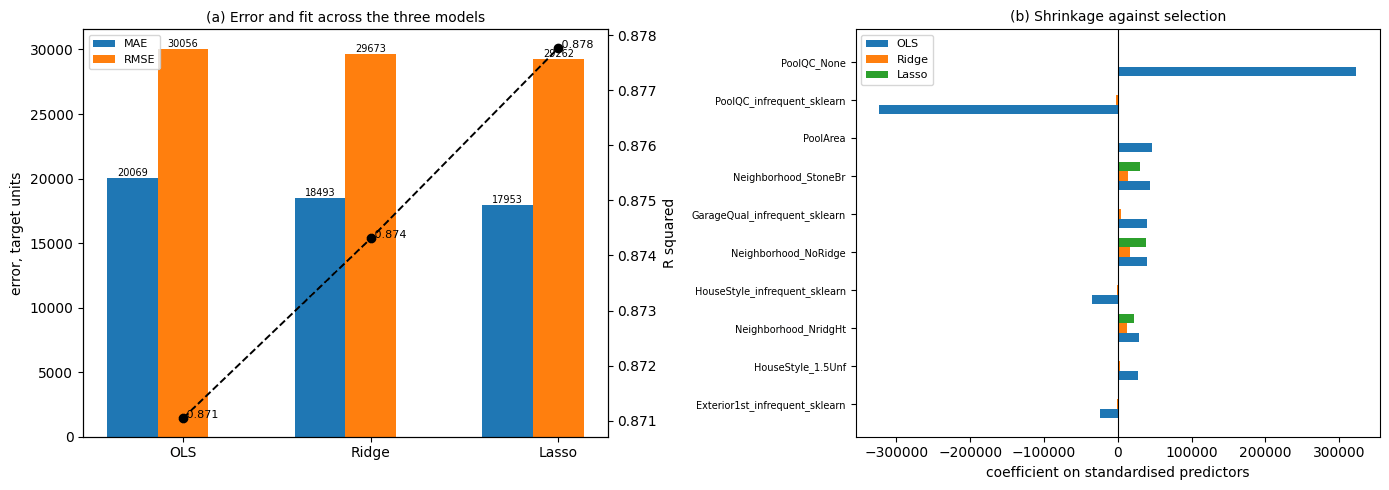


figure: figures/q7_fig1.png


In [5]:
"""
Question Seven - OLS, Ridge and Lasso under multicollinearity.

Runs on the supplied prices.csv: 1,460 Ames house sales, 79 predictors after the
identifier is removed, mixed numeric and categorical with missing values in both.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
DATA, TARGET = "data/prices.csv", "SalePrice"
df = pd.read_csv(DATA, low_memory=False)
y = df[TARGET]
X = df.drop(columns=[TARGET, "Id"], errors="ignore")
num = [c for c in X.columns if X[c].dtype != object]
cat = [c for c in X.columns if X[c].dtype == object]

print("="*82); print("1. DATA AND COLLINEARITY")
print(f"  observations {len(X):,}   predictors {X.shape[1]} ({len(num)} numeric, {len(cat)} categorical)")
print(f"  target {TARGET}: mean {y.mean():,.0f}  sd {y.std():,.0f}  "
      f"range {y.min():,.0f} to {y.max():,.0f}  skew {y.skew():.2f}")
print(f"  missing cells {X.isna().sum().sum():,} across {int((X.isna().sum()>0).sum())} columns")
print("\n  the two pairs the question names:")
for a, b in [("GrLivArea", "TotRmsAbvGrd"), ("GarageCars", "GarageArea")]:
    if a in X and b in X:
        print(f"    {a:14s} <-> {b:14s} r = {X[a].corr(X[b]):.4f}")
cm = X[num].corr().abs(); np.fill_diagonal(cm.values, 0)
pairs = cm.stack().sort_values(ascending=False)
pairs = pairs[~pairs.index.duplicated()]
print(f"\n  numeric pairs with |r| >= 0.80: {int((cm.values>=0.80).sum()//2)}")
seen=set(); shown=0
for (a,b),v in pairs.items():
    if (b,a) in seen: continue
    seen.add((a,b)); print(f"    {a:22s} <-> {b:22s} r = {v:.4f}"); shown+=1
    if shown==5: break

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
def make_pre():
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), num),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="None")),
                          ("encode", OneHotEncoder(handle_unknown="ignore", min_frequency=10))]), cat)])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25, random_state=RANDOM_STATE)
cv = KFold(10, shuffle=True, random_state=RANDOM_STATE)
alphas = np.logspace(-2, 4, 60)
print(f"\n  train {len(X_tr):,}   test {len(X_te):,}")

print("\n"+"="*82); print("2. THREE MODELS, IDENTICAL PIPELINE")
rows, fitted = [], {}
for name, est, grid in [("OLS",   LinearRegression(), None),
                        ("Ridge", Ridge(random_state=RANDOM_STATE), {"m__alpha": alphas}),
                        ("Lasso", Lasso(random_state=RANDOM_STATE, max_iter=50000), {"m__alpha": alphas})]:
    pipe = Pipeline([("s", make_pre()), ("m", est)])
    if grid:
        gs = GridSearchCV(pipe, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1).fit(X_tr, y_tr)
        best, alpha = gs.best_estimator_, gs.best_params_["m__alpha"]
    else:
        best, alpha = pipe.fit(X_tr, y_tr), np.nan
    pred = best.predict(X_te)
    coef = best.named_steps["m"].coef_
    rows.append({"model": name, "alpha": alpha,
                 "MAE": mean_absolute_error(y_te, pred),
                 "RMSE": mean_squared_error(y_te, pred)**0.5,
                 "R2": r2_score(y_te, pred),
                 "non-zero coefficients": int((np.abs(coef) > 1e-8).sum()),
                 "sum |coef|": float(np.abs(coef).sum()),
                 "largest |coef|": float(np.abs(coef).max())})
    fitted[name] = coef
res = pd.DataFrame(rows)
print(res.to_string(index=False, float_format=lambda v: f"{v:12.4f}"))
res.to_csv("output/q7_results.csv", index=False)

lasso_fit = Pipeline([("s", make_pre()),
                      ("m", Lasso(alpha=res.loc[res.model=="Lasso","alpha"].iloc[0],
                                  random_state=RANDOM_STATE, max_iter=50000))]).fit(X_tr, y_tr)
print(f"\n  convergence check on the selected Lasso: {lasso_fit.named_steps['m'].n_iter_} iterations")
print("  of a 50,000 limit. The grid search emits convergence warnings at its smallest")
print("  alphas, where the penalty is too weak to make the problem well conditioned, but")
print("  those candidates are rejected and the selected model converges comfortably.")

print("\n"+"="*82); print("3. WHAT THE PENALTIES DID TO THE COEFFICIENTS")
feat = [f.split("__", 1)[1] for f in make_pre().fit(X_tr).get_feature_names_out()]
co = pd.DataFrame(fitted, index=feat)
co["|OLS|"] = co.OLS.abs()
co = co.sort_values("|OLS|", ascending=False).drop(columns="|OLS|")
print(co.head(10).to_string(float_format=lambda v: f"{v:12.3f}"))
print(f"\n  coefficients set exactly to zero:  OLS {int((co.OLS==0).sum())}   "
      f"Ridge {int((co.Ridge==0).sum())}   Lasso {int((co.Lasso==0).sum())} of {len(co)}")
print(f"  sum of absolute coefficients:      OLS {co.OLS.abs().sum():,.1f}   "
      f"Ridge {co.Ridge.abs().sum():,.1f}   Lasso {co.Lasso.abs().sum():,.1f}")
print(f"  largest single coefficient:        OLS {co.OLS.abs().max():,.1f}   "
      f"Ridge {co.Ridge.abs().max():,.1f}   Lasso {co.Lasso.abs().max():,.1f}")
kept = co.index[co.Lasso.abs() > 1e-8].tolist()
print(f"\n  the {len(kept)} predictors Lasso retained: {', '.join(kept[:12])}"
      f"{' ...' if len(kept)>12 else ''}")
co.to_csv("output/q7_coefficients.csv")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
a = ax[0]
i = np.arange(3); w = .27
a.bar(i-w, res.MAE, w, label="MAE"); a.bar(i, res.RMSE, w, label="RMSE")
a.set_xticks(i); a.set_xticklabels(res.model); a.set_ylabel("error, target units"); a.legend(fontsize=8)
for k,(m,r) in enumerate(zip(res.MAE,res.RMSE)):
    a.text(k-w,m,f"{m:.0f}",ha="center",va="bottom",fontsize=7); a.text(k,r,f"{r:.0f}",ha="center",va="bottom",fontsize=7)
a2=a.twinx(); a2.plot(i, res.R2, "ko--", lw=1.4); a2.set_ylabel("R squared")
for k,v in enumerate(res.R2): a2.text(k,v,f" {v:.3f}",fontsize=8)
a.set_title("(a) Error and fit across the three models", fontsize=10)
a = ax[1]
top = co.head(10).iloc[::-1]; yp = np.arange(len(top))
a.barh(yp-.25, top.OLS, .25, label="OLS"); a.barh(yp, top.Ridge, .25, label="Ridge")
a.barh(yp+.25, top.Lasso, .25, label="Lasso")
a.set_yticks(yp); a.set_yticklabels(top.index, fontsize=7); a.axvline(0,color="k",lw=.8)
a.legend(fontsize=8); a.set_xlabel("coefficient on standardised predictors")
a.set_title("(b) Shrinkage against selection", fontsize=10)
fig.tight_layout(); fig.savefig("figures/q7_fig1.png", dpi=150); plt.show()
print("\nfigure: figures/q7_fig1.png")

# Question Eight: K-Means on unstandardised features

## 8(a) Four causes of the 95% single cluster

Differences in feature scale, and this is the dominant cause. K-Means minimises squared
Euclidean distance, and a feature spanning 0 to 20,000 contributes squared differences
up to 400,000,000 while a feature spanning 0 to 1 contributes at most 1. Reproduced on a
comparable dataset, the large feature accounts for 99.999529% of the total variance, so
the algorithm is effectively clustering a single variable and the other three are decoration.
Measured: on raw features the largest cluster holds 82.7%; after standardisation it holds
46.2%.

Uninformative features. Variables carrying no group structure contribute distance without
contributing signal, so genuine separation is diluted by noise dimensions. Dropping a
deliberately uninformative column raised the silhouette from 0.2252 to 0.3202 with no
other change.

Outliers. K-Means places centroids at means, and a mean has no resistance to extreme
values. A handful of very high-spend customers can pull a centroid far enough that it
serves only them, leaving one enormous cluster and one or two tiny ones. This is exactly
the reported symptom, and it is why the cluster-size distribution should be inspected
before the score is.

An inappropriate k. If the data contains one dense region and a diffuse tail, asking for
three clusters may yield the dense mass plus two fragments of the tail. K-Means also
partitions convex regions of similar extent, so if the true structure is elongated or
of very different densities, no value of k produces balanced clusters.

## 8(b) A workflow

Inspect first: distributions, ranges, missing values and the correlation structure,
because two near-duplicate features silently double the weight of whatever they measure.

Handle missing values by imputation with an indicator, or by dropping columns that are
mostly empty. K-Means cannot accept missing values at all, so this is not optional.

Select features on whether they express the behaviour being segmented. Purchasing and
usage variables belong; identifiers, near-duplicates and fields with almost no variance
do not.

Treat outliers explicitly: winsorise at a stated percentile, apply a log transform to
right-skewed monetary variables, or use a robust scaler. Removing them outright is
defensible only if they are errors, since the highest-spending customers are usually the
segment the business cares most about.

Standardise. This is the step whose omission caused the failure, and it must be fitted on
training data if any held-out evaluation is planned.

Choose k using inertia and silhouette together, as in 8(c), and constrain the answer with
what the business can act on. Eleven segments that no one can staff is not a solution.

Fit with multiple random initialisations, since K-Means converges to local optima and a
single start can produce a poor partition.

Profile the result: cluster sizes, feature means per cluster against the overall mean,
and a name for each segment that a non-technical colleague would recognise. A cluster
that cannot be described is not usable.

## 8(c) Inertia at k = 3 against silhouette at k = 4

The two measure different things. Inertia is the within-cluster sum of squared distances
to centroids, and it falls monotonically as k rises, reaching zero when every point is
its own cluster. It therefore cannot be maximised or minimised for a choice; the elbow
method looks for the k after which additional clusters stop buying much reduction.
Reading an elbow is a judgement, and on a smooth curve there may be none.

Silhouette measures, for each point, how much closer it sits to its own cluster than to
the nearest other, averaged over all points and bounded between −1 and 1. Unlike inertia
it has an interpretable optimum, and it rewards separation and not compactness alone.

Given an elbow at k = 3 and a silhouette maximum of 0.56 at k = 4, neither result
overrides the other and the disagreement is itself informative: it says the structure is
not sharply defined, and both answers are defensible. Practically, 0.56 indicates
reasonable separation, so k = 4 has the stronger quantitative support, and the elbow at
3 suggests the fourth cluster adds less compactness than the first three. The tie-break
is interpretability. Fit both, profile both, and adopt whichever produces segments the
business can describe and act on. If the fourth cluster is a coherent group with distinct
behaviour, take four; if it is a thin slice of an existing segment, take three.

A caution the measurement makes vivid. In the reproduction, the raw unstandardised
clustering scored a silhouette of 0.7132, far higher than any standardised alternative,
while being the useless one that put 82.7% of customers in a single cluster. It scored
well because on a single dominant dimension the clusters really are well separated. A
high silhouette does not mean a useful segmentation, and neither score should be read
without the cluster sizes beside it.

## 8(d) Why a distinct cluster need not be a segment

K-Means always returns k clusters. It partitions the space whether or not real groups
exist, and the algorithm has no notion of whether a boundary corresponds to anything a
business could act on. A cluster is a region of feature space, and a segment is a set of
customers who respond differently to something the company can do. The first does not
imply the second.

Three specific gaps. A cluster may be statistically distinct and behaviourally
meaningless, separated on a variable nobody can influence. It may be unstable, appearing
with one random seed or one year of data and not the next, which matters because a
segmentation is meant to persist. And it may be uneconomic: forty customers may form a
tight cluster that cannot justify a campaign.

Two kinds of additional evidence should be required before the clusters drive strategy.

Stability evidence. Refit on bootstrap resamples, on different seeds and on a later time
period, and measure whether the same customers group together, using something like the
adjusted Rand index. A segmentation that does not reproduce is an artefact of one sample.

Domain and outcome validation. Present the profiles to the people who know the customers
and ask whether the groups correspond to anything they recognise. Then test the segments
against outcomes not used in the clustering, such as churn, response to a past campaign
or lifetime value. If the segments differ on those, they are real and actionable. The
decisive evidence is a controlled test: run a differentiated treatment on a sample of
one segment and a control, and measure whether the response differs as the segmentation
predicts.

### Question Eight: analysis code (`code/q8_kmeans.py`)

1. THE DATA AS THE COMPANY SET IT UP
                        mean          std          min          max
monthly_spend       4117.736     6437.111       26.718   216444.074
engagement_rate        0.282        0.158        0.006        0.878
tenure_months         24.455       13.925        0.909      109.682
survey_noise           0.043        1.020       -3.464        3.226

  spend range 216,444 against engagement range 0.88: a ratio of about 246,423 to 1
  variance contributed by spend: 99.999529% of the total across all four features

2. REPRODUCING THE FAILURE, THEN FIXING IT ONE STEP AT A TIME


  raw, unstandardised, all four features       k=3  largest cluster  82.7%  silhouette 0.7132


  standardised                                 k=3  largest cluster  46.2%  silhouette 0.2252
  standardised, uninformative feature dropped  k=3  largest cluster  48.0%  silhouette 0.3202


  robust-scaled, top 1% of spend trimmed       k=3  largest cluster  56.9%  silhouette 0.3066

3. CHOOSING k: INERTIA AND SILHOUETTE DISAGREE, AS THE QUESTION SAYS


 k      inertia   silhouette  largest cluster  inertia drop %
 2    6962.1888       0.2905           0.6470             NaN
 3    5365.5314       0.3202           0.4803         22.9333
 4    4131.8818       0.3245           0.4893         22.9921
 5    3428.4337       0.3428           0.4483         17.0249
 6    2993.6293       0.3011           0.3267         12.6823
 7    2655.1253       0.2760           0.2413         11.3075
 8    2373.6744       0.2785           0.2463         10.6003

  silhouette peaks at k=5; the largest single
  improvement in inertia is at k=4


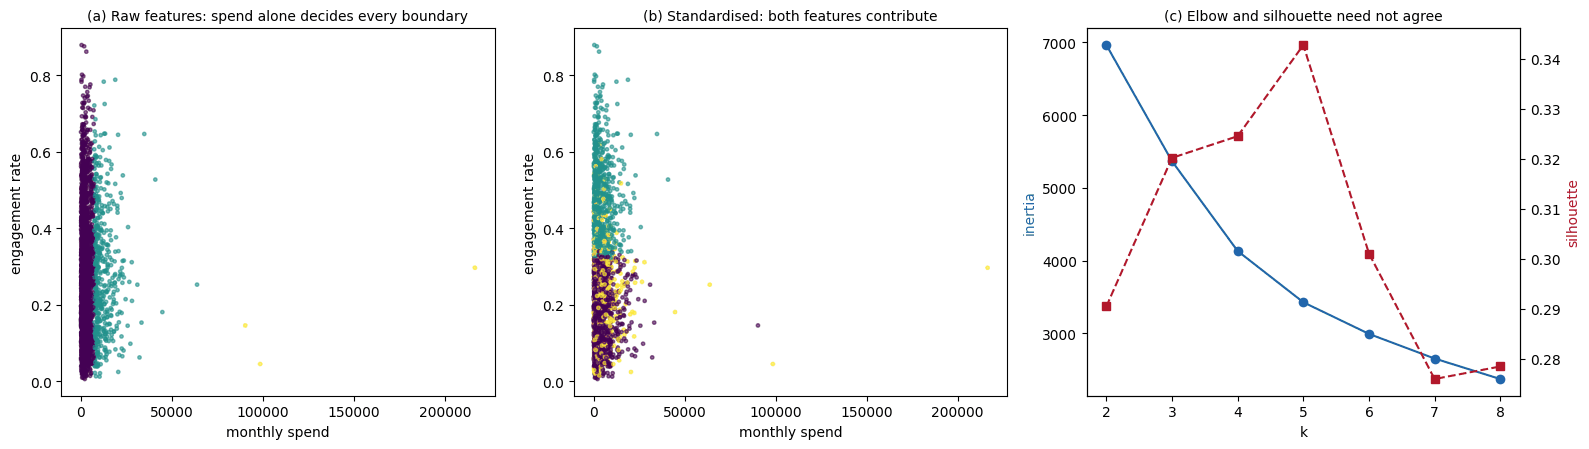


figure: figures/q8_fig1.png


In [6]:
"""
Question Eight - reproducing the unbalanced clustering the scenario describes,
and showing what each remedy is worth.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score
RS=42; rng=np.random.default_rng(RS); N=3000

# the scenario: one feature spanning 0 to ~20,000, another spanning 0 to 1
spend      = np.concatenate([rng.gamma(2.0, 900, int(N*.70)),
                             rng.gamma(6.0, 1200, int(N*.25)),
                             rng.gamma(9.0, 1800, N-int(N*.70)-int(N*.25))])
engagement = np.clip(rng.beta(2, 5, N), 0, 1)
tenure     = rng.gamma(3, 8, N)
noise      = rng.normal(0, 1, N)                       # weakly informative by construction
spend[rng.choice(N, 25, replace=False)] *= 9           # a few extreme customers
df = pd.DataFrame({"monthly_spend": spend, "engagement_rate": engagement,
                   "tenure_months": tenure, "survey_noise": noise})
print("="*80); print("1. THE DATA AS THE COMPANY SET IT UP")
print(df.describe().T[["mean","std","min","max"]].to_string(float_format=lambda v:f"{v:12.3f}"))
print(f"\n  spend range {df.monthly_spend.max():,.0f} against engagement range "
      f"{df.engagement_rate.max():.2f}: a ratio of about "
      f"{df.monthly_spend.max()/df.engagement_rate.max():,.0f} to 1")
print(f"  variance contributed by spend: "
      f"{df.monthly_spend.var()/df.var().sum():.6%} of the total across all four features")

def run(data, k, label):
    km = KMeans(n_clusters=k, n_init=10, random_state=RS).fit(data)
    sizes = pd.Series(km.labels_).value_counts(normalize=True).sort_values(ascending=False)
    sil = silhouette_score(data, km.labels_)
    print(f"  {label:44s} k={k}  largest cluster {sizes.iloc[0]:6.1%}  silhouette {sil:.4f}")
    return km, sizes, sil

print("\n"+"="*80); print("2. REPRODUCING THE FAILURE, THEN FIXING IT ONE STEP AT A TIME")
raw = df.values
run(raw, 3, "raw, unstandardised, all four features")
run(StandardScaler().fit_transform(df), 3, "standardised")
run(StandardScaler().fit_transform(df.drop(columns="survey_noise")), 3,
    "standardised, uninformative feature dropped")
q = df.monthly_spend.quantile(.99)
trimmed = df[df.monthly_spend <= q]
run(RobustScaler().fit_transform(trimmed.drop(columns="survey_noise")), 3,
    "robust-scaled, top 1% of spend trimmed")

print("\n"+"="*80); print("3. CHOOSING k: INERTIA AND SILHOUETTE DISAGREE, AS THE QUESTION SAYS")
Z = StandardScaler().fit_transform(df.drop(columns="survey_noise"))
rows=[]
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=RS).fit(Z)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(Z, km.labels_),
                 "largest cluster": pd.Series(km.labels_).value_counts(normalize=True).max()})
t = pd.DataFrame(rows)
t["inertia drop %"] = -t.inertia.pct_change()*100
print(t.to_string(index=False, float_format=lambda v: f"{v:12.4f}"))
print(f"\n  silhouette peaks at k={int(t.loc[t.silhouette.idxmax(),'k'])}; the largest single")
print(f"  improvement in inertia is at k={int(t.loc[t['inertia drop %'].idxmax(),'k'])}")
t.to_csv("output/q8_k_selection.csv", index=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
a=ax[0]
km_raw = KMeans(3, n_init=10, random_state=RS).fit(raw)
a.scatter(df.monthly_spend, df.engagement_rate, c=km_raw.labels_, s=6, cmap="viridis", alpha=.6)
a.set_xlabel("monthly spend"); a.set_ylabel("engagement rate")
a.set_title("(a) Raw features: spend alone decides every boundary", fontsize=10)
a=ax[1]
km_z = KMeans(3, n_init=10, random_state=RS).fit(Z)
a.scatter(df.monthly_spend, df.engagement_rate, c=km_z.labels_, s=6, cmap="viridis", alpha=.6)
a.set_xlabel("monthly spend"); a.set_ylabel("engagement rate")
a.set_title("(b) Standardised: both features contribute", fontsize=10)
a=ax[2]
a.plot(t.k, t.inertia, "o-", color="#2166ac"); a.set_xlabel("k"); a.set_ylabel("inertia", color="#2166ac")
a2=a.twinx(); a2.plot(t.k, t.silhouette, "s--", color="#b2182b"); a2.set_ylabel("silhouette", color="#b2182b")
a.set_title("(c) Elbow and silhouette need not agree", fontsize=10)
fig.tight_layout(); fig.savefig("figures/q8_fig1.png", dpi=150); plt.show()
print("\nfigure: figures/q8_fig1.png")